# Fast Mercury porkchop example

This notebook creates three small Mercury porkchops: one with the high-order hodographic method, one with a quintic cylindrical B-spline using 10 control points, and one with a degree-nine Bézier curve using 10 control points.

## Important simplifications

This is a **quick workflow demonstration**, not the publication campaign. It deliberately uses:

- exactly 10 departure dates and 10 transfer times (100 grid points);
- one Earth-Mercury synodic period beginning on 1 January 2028;
- transfer times restricted to 100-700 days instead of the full study range;
- only revolution branches $N=0$ and $N=1$, rather than $N=0,\ldots,5$;
- the built-in Keplerian ephemeris rather than SPICE;
- reduced hodographic quadrature and optimizer evaluation limits;
- reduced B-spline fine-grid resolution and serial neighboring-point continuation.

These choices reduce the example to 600 branch attempts in total. Use the command-line campaign scripts with SPICE, the complete branch range, and the desired grid spacing for scientific results.

In [1]:
from argparse import Namespace
from datetime import datetime, timedelta
from pathlib import Path
from time import perf_counter
import sys

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm, ListedColormap
import numpy as np

ROOT = Path.cwd()
if not (ROOT / "experiments").exists():
    ROOT = ROOT.parent
if not (ROOT / "experiments").exists():
    raise RuntimeError("Run this notebook from the FASTTRANSFER repository or notebooks directory.")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from experiments.reproduce_gondelach_fig2 import ELEMENTS, configure_ephemeris
from experiments.reproduce_gondelach_fig2_bspline_cylindrical import run_tasks as run_bspline_grid
from experiments.reproduce_gondelach_fig3 import compute_grid as run_hodographic_grid

configure_ephemeris("kepler")
plt.rcParams.update({"font.size": 12, "axes.grid": True, "grid.alpha": 0.22})

## Define the demonstration grid

The departure window spans one approximate synodic period,

$$T_{\mathrm{syn}}=\left|\frac{1}{T_{\mathrm{Mercury}}}-\frac{1}{T_{\mathrm{Earth}}}\right|^{-1}.$$

A spacing of $T_{\mathrm{syn}}/9$ gives exactly 10 departure dates including both endpoints. The TOF spacing is defined in the same way.

In [2]:
MJD2000_EPOCH = datetime(2000, 1, 1, 12)
DEPARTURE_MIN = 10226.5  # 2028-01-01 00:00

earth_period_days = 365.25 * ELEMENTS["earth"].a**1.5
mercury_period_days = 365.25 * ELEMENTS["mercury"].a**1.5
synodic_period_days = 1.0 / abs(1.0 / mercury_period_days - 1.0 / earth_period_days)

DEPARTURE_MAX = DEPARTURE_MIN + synodic_period_days
DEPARTURE_STEP = synodic_period_days / 9.0
TOF_MIN = 100.0
TOF_MAX = 700.0
TOF_STEP = (TOF_MAX - TOF_MIN) / 9.0
N_MIN, N_MAX = 0, 1

print(f"Earth-Mercury synodic period: {synodic_period_days:.3f} days")
print(f"Departure window: {MJD2000_EPOCH + timedelta(days=DEPARTURE_MIN)} to "
      f"{MJD2000_EPOCH + timedelta(days=DEPARTURE_MAX)}")
print("Grid: 10 departure dates x 10 TOFs x 2 branches x 3 methods = 600 branch attempts")

Earth-Mercury synodic period: 115.876 days
Departure window: 2028-01-01 00:00:00 to 2028-04-25 21:01:29.092020
Grid: 10 departure dates x 10 TOFs x 2 branches x 3 methods = 600 branch attempts


## High-order hodographic grid

The Mercury high-order basis has six free coefficients. For speed, neighboring solutions warm-start the next grid point automatically, while each local SciPy Nelder-Mead solve is limited to 150 function evaluations.

In [3]:
MERCURY_HIGH_ORDER_BASIS = (
    "CPowPow2PSinPCos-"
    "CPowPow2PSinPCos-"
    "Cos05Pow5Pow6P6Cos05P6Sin05"
)

hodographic_args = Namespace(
    basis=MERCURY_HIGH_ORDER_BASIS,
    target="mercury",
    dep_min=DEPARTURE_MIN,
    dep_max=DEPARTURE_MAX,
    dep_step=DEPARTURE_STEP,
    tof_min=TOF_MIN,
    tof_max=TOF_MAX,
    tof_step=TOF_STEP,
    n_min=N_MIN,
    n_max=N_MAX,
    n_quad=101,
    maxfev=150,
    xatol=1.0e-4,
    fatol=1.0e-4,
    simplex_scale=0.05,
    optimizer="scipy",
    oneill_reqmin=1.0e-8,
    oneill_konvge=10,
    oneill_factorial_epsilon=1.0e-3,
    progress=False,
    progress_every=20,
)

start = perf_counter()
departure_grid, tof_grid, hodographic_rows, hodographic_dv, hodographic_best_n = (
    run_hodographic_grid(hodographic_args)
)
hodographic_runtime = perf_counter() - start
print(f"Hodographic runtime: {hodographic_runtime:.2f} s")
print(f"Usable grid points: {np.isfinite(hodographic_dv).sum()}/{hodographic_dv.size}")

Hodographic runtime: 16.88 s
Usable grid points: 100/100


## Quintic B-spline grid

The B-spline grid uses 10 control points, sixth-order Gauss-Legendre objective quadrature, and the nominal fixed endpoint control points. Neighboring usable solutions provide serial continuation seeds.

In [4]:
bspline_args = Namespace(
    dep_min=DEPARTURE_MIN,
    dep_max=DEPARTURE_MAX,
    dep_step=DEPARTURE_STEP,
    tof_min=TOF_MIN,
    tof_max=TOF_MAX,
    tof_step=TOF_STEP,
    n_min=N_MIN,
    n_max=N_MAX,
    target="mercury",
    n_ctrl=10,
    degree=5,
    n_fine=151,
    seed_profile="quintic",
    quadrature_order=6,
    r_bound=20.0,
    dv_eps=1.0e-6,
    smoothness_weight=0.0,
    endpoint_control_weight=0.0,
    max_iter=250,
    print_level=0,
    kepler_substeps=80,
    accept_debug_feasible=False,
    endpoint_tol=1.0e-6,
    winding_tol_rev=1.0e-3,
    workers=1,
    grid_continuation=True,
    grid_continuation_project=True,
    progress=False,
    progress_every=20,
    linear_solver="mumps",
    coinhsl_library="",
    ephemeris="kepler",
    spice_meta_kernel="",
    spice_target_name="",
)

start = perf_counter()
_, _, bspline_rows, bspline_dv, bspline_best_n = run_bspline_grid(bspline_args)
bspline_runtime = perf_counter() - start
print(f"B-spline runtime: {bspline_runtime:.2f} s")
print(f"Usable grid points: {np.isfinite(bspline_dv).sum()}/{bspline_dv.size}")


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************



B-spline runtime: 26.93 s
Usable grid points: 100/100


## Degree-nine Bézier grid

The Bézier comparison keeps the same number of control points as the B-spline. Setting $n_c=10$ makes the clamped basis a single polynomial span of degree $p=n_c-1=9$, exactly equivalent to the degree-nine Bernstein basis of a Bézier curve, and leaves the same six free control points after the analytical endpoint elimination. Comparing at equal $n_c$ rather than at equal degree matches the published campaign; a Bézier curve cannot match both at once.

The single knot span also means the composite Gauss-Legendre objective quadrature spreads `quadrature_order` nodes over the whole transfer instead of over each of the five B-spline spans, so the order is raised to 30 here.

In [5]:
bezier_args = Namespace(**vars(bspline_args))
bezier_args.n_ctrl = bspline_args.n_ctrl
bezier_args.degree = bezier_args.n_ctrl - 1
bezier_args.quadrature_order = 30
bezier_args.max_iter = 700

start = perf_counter()
_, _, bezier_rows, bezier_dv, bezier_best_n = run_bspline_grid(bezier_args)
bezier_runtime = perf_counter() - start
print(f"Bézier runtime: {bezier_runtime:.2f} s")
print(f"Usable grid points: {np.isfinite(bezier_dv).sum()}/{bezier_dv.size}")

Bézier runtime: 29.33 s
Usable grid points: 96/100


## Quick-look porkchops

All three panels use the same fixed Mercury $\Delta V$ buckets and blue-to-green palette as the paper postprocessing. Values above 160 km/s use the colorbar's upper extension. The black dots show the actual 100 sampled grid points.

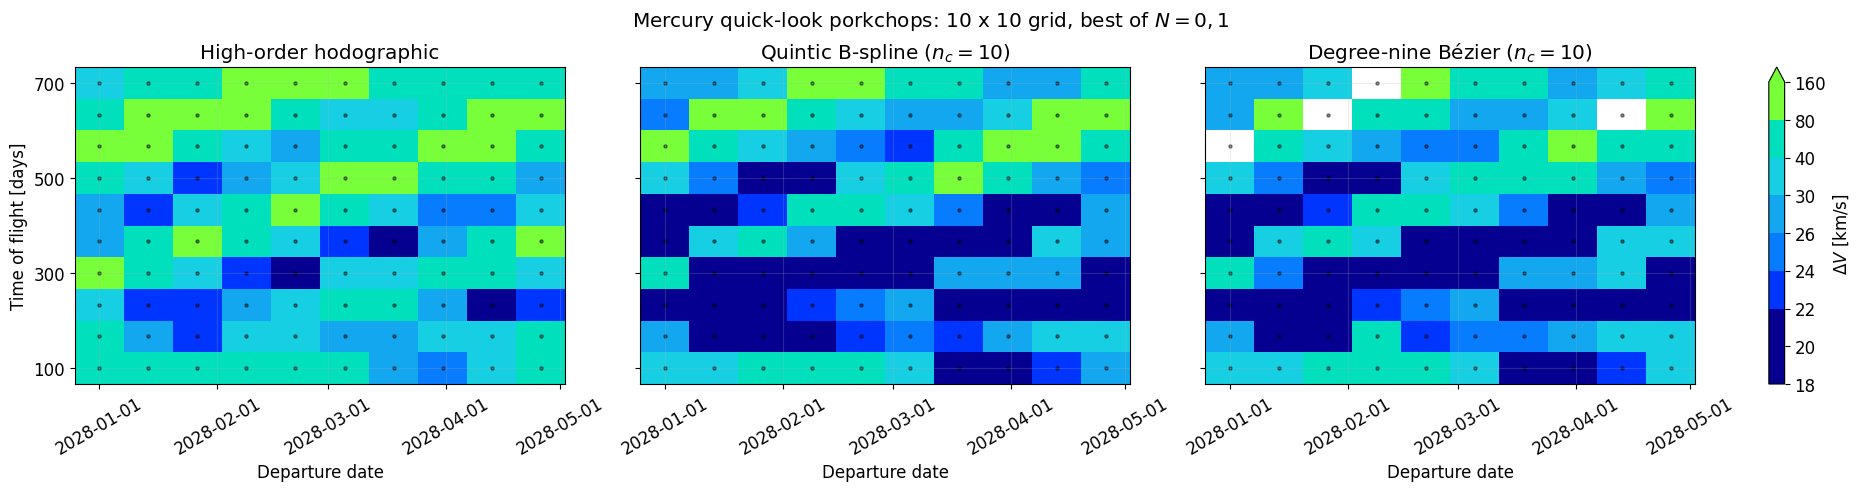

In [6]:
departure_dates = np.asarray(
    [MJD2000_EPOCH + timedelta(days=float(value)) for value in departure_grid]
)
delta_v_bins = np.array([18.0, 20.0, 22.0, 24.0, 26.0, 30.0, 40.0, 80.0, 160.0])
gondelach_blue = ListedColormap(
    ["#05008f", "#0035ff", "#087cff", "#12a7ee", "#17cfe2", "#00e0bd", "#78ff3a"],
    name="gondelach_blue",
).resampled(len(delta_v_bins))
norm = BoundaryNorm(delta_v_bins, gondelach_blue.N, clip=False, extend="max")

fig, axes = plt.subplots(1, 3, figsize=(18.5, 4.8), sharex=True, sharey=True, constrained_layout=True)
titles = (
    "High-order hodographic",
    r"Quintic B-spline ($n_c=10$)",
    r"Degree-nine Bézier ($n_c=10$)",
)
grids = (hodographic_dv, bspline_dv, bezier_dv)

for ax, title, delta_v in zip(axes, titles, grids):
    mesh = ax.pcolormesh(departure_dates, tof_grid, delta_v, shading="nearest", cmap=gondelach_blue, norm=norm)
    dep_mesh, tof_mesh = np.meshgrid(departure_dates, tof_grid)
    ax.scatter(dep_mesh.ravel(), tof_mesh.ravel(), s=5, color="black", alpha=0.45)
    ax.set_title(title)
    ax.set_xlabel("Departure date")
    ax.set_yticks([100, 300, 500, 700])
    ax.xaxis.set_major_locator(mdates.AutoDateLocator(minticks=4, maxticks=6))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
    ax.tick_params(axis="x", rotation=30)

axes[0].set_ylabel("Time of flight [days]")
colorbar = fig.colorbar(
    mesh,
    ax=axes,
    pad=0.02,
    boundaries=delta_v_bins,
    ticks=delta_v_bins,
    extend="max",
)
colorbar.set_label(r"$\Delta V$ [km/s]")
fig.suptitle("Mercury quick-look porkchops: 10 x 10 grid, best of $N=0,1$")
plt.show()

## Minimum sampled solutions

These values are minima of the coarse demonstration grid only. They should not be quoted as converged campaign optima.

In [7]:
def report_minimum(name, delta_v, best_n):
    if not np.isfinite(delta_v).any():
        print(f"{name}: no usable solution on this demonstration grid")
        return
    i_tof, i_dep = np.unravel_index(np.nanargmin(delta_v), delta_v.shape)
    date = MJD2000_EPOCH + timedelta(days=float(departure_grid[i_dep]))
    print(
        f"{name}: Delta V = {delta_v[i_tof, i_dep]:.3f} km/s, "
        f"departure = {date:%Y-%m-%d}, TOF = {tof_grid[i_tof]:.1f} days, "
        f"N = {best_n[i_tof, i_dep]}"
    )

report_minimum("High-order hodographic", hodographic_dv, hodographic_best_n)
report_minimum("Quintic B-spline", bspline_dv, bspline_best_n)
report_minimum("Degree-nine Bézier", bezier_dv, bezier_best_n)
total_runtime = hodographic_runtime + bspline_runtime + bezier_runtime
print(f"Total notebook grid runtime: {total_runtime:.2f} s")

High-order hodographic: Delta V = 20.643 km/s, departure = 2028-03-18, TOF = 366.7 days, N = 1
Quintic B-spline: Delta V = 18.962 km/s, departure = 2028-01-26, TOF = 166.7 days, N = 0
Degree-nine Bézier: Delta V = 18.982 km/s, departure = 2028-01-26, TOF = 166.7 days, N = 0
Total notebook grid runtime: 73.15 s
